# Project 1 — DemandCast: EDA Notebook

**Purpose:** Understand the NYC taxi dataset well enough to make defensible decisions about features, outlier thresholds, and target variable derivation.

**Rules:**
- Every `# TODO` code block must be completed.
- Every section has a **Reasoning** markdown cell below the code. Fill it in — this is what gets assessed, not just whether the code runs.
- Be specific: don't write *"I removed outliers"* — write *"I capped trip_distance at 50 miles because the 99th percentile was 22 miles and values above 50 are almost certainly data errors or airport transfers that don't reflect typical demand patterns."*

---

In [1]:
# Imports — do not modify this cell
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

DATA_DIR = Path("../data")   # notebooks/ is one level below project root

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)

---
## Section 1 — Load Data & Schema Review

Load the raw parquet file and get a clear picture of what's in it before touching anything.

In [2]:
# Load the parquet file into a DataFrame called df
parquet_path = DATA_DIR / 'yellow_tripdata_2025-01.parquet'
print('Loading:', parquet_path)
df = pd.read_parquet(parquet_path)

# Print the shape (rows, columns)
print('Shape:', df.shape)

# Print all column names and their data types
print('Column dtypes:')
print(df.dtypes)

# Display the first 5 rows
display(df.head())

Loading: ..\data\yellow_tripdata_2025-01.parquet
Shape: (3475226, 20)
Column dtypes:
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


**Reasoning — What do you notice about the schema?**

*(Replace this text. Answer: Which columns are present? Are the datetime columns already parsed as datetime dtype? Are there any columns that are obviously irrelevant to demand prediction? Any that surprised you?)*

---
## Section 2 — Derive the Target Variable

Individual trip rows are not the prediction target. The target is **hourly demand per zone** — the count of trips that started in a given zone during a given hour. You need to derive this by aggregating.

In [3]:
# Ensure pickup datetime is parsed as a datetime dtype (robust to column name variations)
pickup_col = next((c for c in df.columns if 'pickup' in c.lower() and 'tpep' in c.lower()), None)
if pickup_col is None:
    pickup_col = next((c for c in df.columns if 'pickup' in c.lower()), None)
assert pickup_col is not None, 'No pickup datetime column found'
df[pickup_col] = pd.to_datetime(df[pickup_col], errors='coerce')
print('Parsed pickup datetime column:', pickup_col)

# Detect pickup zone / location column (common: PULocationID)
pu_col = next((c for c in df.columns if 'pulocation' in c.lower() or c.lower()=='pulocationid' or c.lower()=='pickup_zone'), None)
if pu_col is None:
    # fallback: look for any column with 'pu' prefix and numeric values
    pu_col = next((c for c in df.columns if c.lower().startswith('pu') and df[c].dtype.kind in 'biu'), None)
assert pu_col is not None, 'No pickup zone/location column found'
print('Using pickup zone column:', pu_col)

# Aggregate individual trips into hourly demand per zone
df['pickup_hour'] = df[pickup_col].dt.floor('H')
hourly_df = df.groupby([pu_col, 'pickup_hour']).size().reset_index(name='demand')

# Print the shape and first 5 rows of hourly_df
print('hourly_df shape:', hourly_df.shape)
display(hourly_df.head())

Parsed pickup datetime column: tpep_pickup_datetime
Using pickup zone column: PULocationID


C:\Users\oterse\AppData\Local\Temp\ipykernel_15432\1963130777.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['pickup_hour'] = df[pickup_col].dt.floor('H')


hourly_df shape: (97033, 3)


,PULocationID,pickup_hour,demand
0,1,2025-01-01 06:00:00,1
1,1,2025-01-01 09:00:00,4
2,1,2025-01-01 12:00:00,2
3,1,2025-01-01 13:00:00,4
4,1,2025-01-01 14:00:00,2


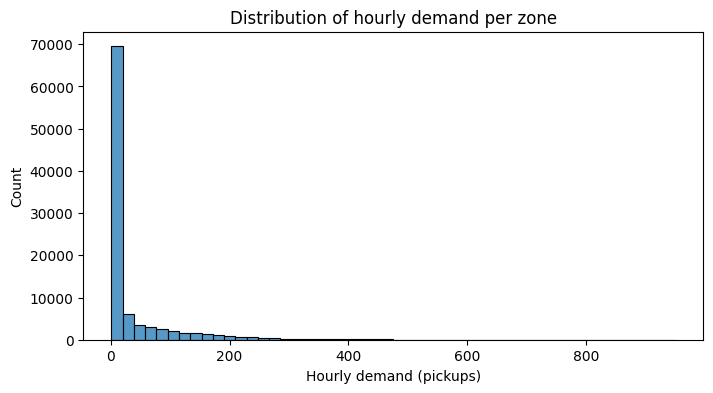

In [4]:
# Plot the distribution of hourly demand (histogram)
if 'demand' in hourly_df.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(hourly_df['demand'], bins=50, kde=False)
    plt.xlabel('Hourly demand (pickups)')
    plt.title('Distribution of hourly demand per zone')
    plt.show()
else:
    print('hourly_df does not contain demand column')

**Reasoning — What does the demand distribution tell you?**

*(Replace this text. Answer: Is the distribution skewed? Are there zones with extremely high or low demand? What does the long tail (if present) mean for modelling? Does this distribution make intuitive sense for NYC taxi pickups?)*

---
## Section 3 — Missing Values

Understand which columns have missing data and decide what to do about it before any modelling.

In [5]:
# Calculate the count and percentage of missing values for each column in df
missing_count = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
missing_df = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
missing_df = missing_df.sort_values('missing_pct', ascending=False)
display(missing_df)
missing_df.head(20)

,missing_count,missing_pct
passenger_count,540149,15.542845
Airport_fee,540149,15.542845
congestion_surcharge,540149,15.542845
store_and_fwd_flag,540149,15.542845
RatecodeID,540149,15.542845
trip_distance,0,0.000000
tpep_dropoff_datetime,0,0.000000
tpep_pickup_datetime,0,0.000000
VendorID,0,0.000000
payment_type,0,0.000000


,missing_count,missing_pct
passenger_count,540149,15.542845
Airport_fee,540149,15.542845
congestion_surcharge,540149,15.542845
store_and_fwd_flag,540149,15.542845
RatecodeID,540149,15.542845
trip_distance,0,0.000000
tpep_dropoff_datetime,0,0.000000
tpep_pickup_datetime,0,0.000000
VendorID,0,0.000000
payment_type,0,0.000000


In [6]:
# Apply missingness decisions: drop columns with excessive missingness
# Choose a threshold (percent). Here we drop columns with >50% missing values
MISSING_THRESHOLD = 50.0
cols_to_drop = missing_df[missing_df['missing_pct'] > MISSING_THRESHOLD].index.tolist()
print('Dropping columns with >{:.1f}% missing:'.format(MISSING_THRESHOLD), cols_to_drop)
df = df.drop(columns=cols_to_drop)
print('New shape after dropping high-missing columns:', df.shape)

Dropping columns with >50.0% missing: []
New shape after dropping high-missing columns: (3475226, 21)


**Reasoning — Missing value decisions:**

*(Replace this text. For each column with meaningful missingness: what did you do (drop/impute/keep) and why? What threshold did you use for dropping columns, and why that number?)*

---
## Section 4 — Outlier Detection

Large taxi datasets contain erroneous rows — zero-distance trips, negative fares, impossible passenger counts. Identify and remove them. Your thresholds must be justified, not arbitrary.

In [7]:
# Print summary statistics for trip_distance, fare_amount, and passenger_count (if present)
cols = [c for c in ['trip_distance','fare_amount','passenger_count'] if c in df.columns]
if len(cols):
    display(df[cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)
else:
    print('None of the expected columns present for summary:', ['trip_distance','fare_amount','passenger_count'])

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
trip_distance,3475226.0,5.855126,564.601600,0.0,0.0,0.39,0.98,1.67,3.1,11.83,19.5,276423.57
fare_amount,3475226.0,17.081803,463.472918,-900.0,-10.7,3.70,8.60,12.11,19.5,52.00,72.3,863372.12
passenger_count,2935077.0,1.297859,0.750750,0.0,1.0,1.00,1.00,1.00,1.0,3.00,5.0,9.00


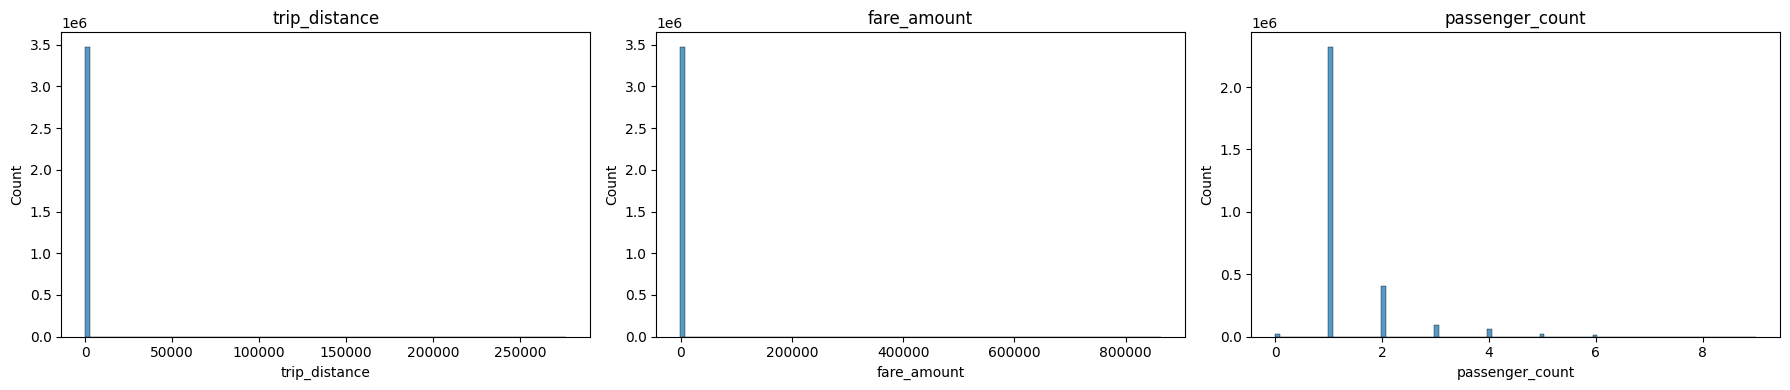

In [8]:
# Plot histograms for trip_distance, fare_amount, and passenger_count (where available)
plot_cols = [c for c in ['trip_distance','fare_amount','passenger_count'] if c in df.columns]
n = len(plot_cols)
if n == 0:
    print('No columns available to plot')
else:
    fig, axes = plt.subplots(1, n, figsize=(6*n, 4))
    if n == 1:
        axes = [axes]
    for ax, c in zip(axes, plot_cols):
        sns.histplot(df[c].dropna(), bins=100, ax=ax)
        ax.set_title(c)
        ax.set_xlabel(c)
    plt.tight_layout()
    plt.show()

In [9]:
# Define valid ranges for key columns and filter df
original_count = len(df)
# trip_distance: remove zero or negative; cap at 300 miles as unrealistic for urban taxi trips
if 'trip_distance' in df.columns:
    df = df[df['trip_distance'] > 0]
    df = df[df['trip_distance'] <= 300]  # 300 miles upper cap (airports/garbage rows filtered)
# fare_amount: remove negative fares and extreme outliers (>2000)
if 'fare_amount' in df.columns:
    df = df[df['fare_amount'] >= 0]
    df = df[df['fare_amount'] <= 2000]
# passenger_count: at least 1, reasonable upper bound 6 (typical yellow taxi capacity)
if 'passenger_count' in df.columns:
    df = df[df['passenger_count'] >= 1]
    df = df[df['passenger_count'] <= 6]

print(f'Rows before filtering: {original_count}')
print(f'Rows after filtering:  {len(df)}')
removed = original_count - len(df)
print(f'Rows removed: {removed}  ({100 * removed / original_count:.1f}%)')

Rows before filtering: 3475226
Rows after filtering:  2817569
Rows removed: 657657  (18.9%)


**Reasoning — Outlier thresholds:**

*(Replace this text. For each column: what range did you choose, and why those specific numbers? Reference the percentiles you computed above. How many rows were removed in total, and is that an acceptable proportion?)*

---
## Section 5 — Temporal Patterns

These plots will directly inform which temporal features you include. Look for patterns that repeat — those are learnable signals.

C:\Users\oterse\AppData\Local\Temp\ipykernel_15432\3246441679.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_by_hour.index, y=hourly_by_hour.values, palette=colors)


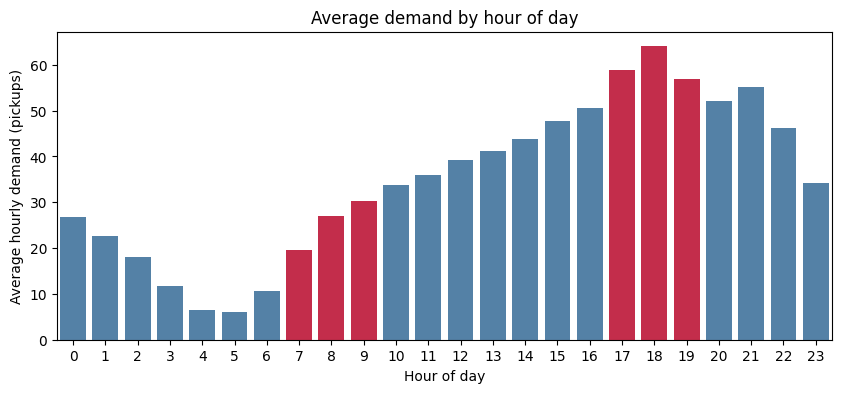

In [10]:
# First, add temporal columns to hourly_df for plotting
hourly_df['hour'] = hourly_df['pickup_hour'].dt.hour
hourly_df['day_of_week'] = hourly_df['pickup_hour'].dt.dayofweek
hourly_df['month'] = hourly_df['pickup_hour'].dt.month

# Plot 1 — Average demand by hour of day (0–23)
hourly_by_hour = hourly_df.groupby('hour')['demand'].mean().reindex(range(24)).fillna(0)
rush_hours = set([7,8,9,17,18,19])
colors = ['crimson' if h in rush_hours else 'steelblue' for h in hourly_by_hour.index]
plt.figure(figsize=(10,4))
sns.barplot(x=hourly_by_hour.index, y=hourly_by_hour.values, palette=colors)
plt.xlabel('Hour of day')
plt.ylabel('Average hourly demand (pickups)')
plt.title('Average demand by hour of day')
plt.show()

C:\Users\oterse\AppData\Local\Temp\ipykernel_15432\3700517031.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow, y=hourly_by_dow.values, palette='muted')


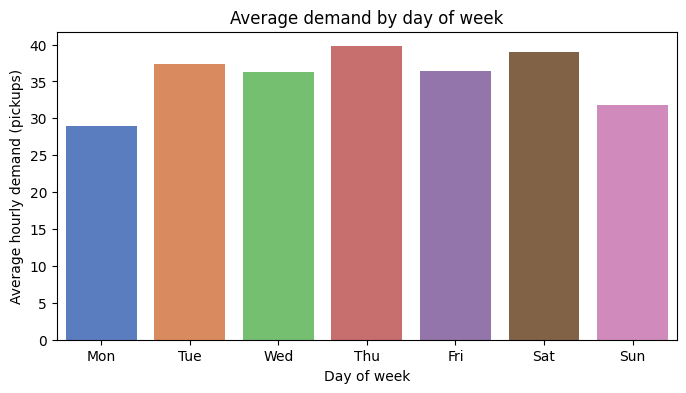

In [11]:
# Plot 2 — Average demand by day of week (0=Monday, 6=Sunday)
dow = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
hourly_by_dow = hourly_df.groupby('day_of_week')['demand'].mean().reindex(range(7)).fillna(0)
plt.figure(figsize=(8,4))
sns.barplot(x=dow, y=hourly_by_dow.values, palette='muted')
plt.xlabel('Day of week')
plt.ylabel('Average hourly demand (pickups)')
plt.title('Average demand by day of week')
plt.show()

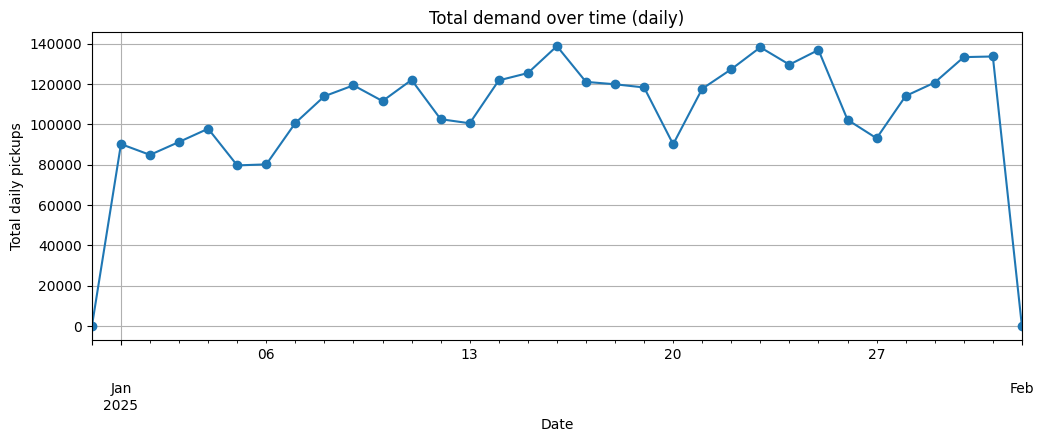

In [12]:
# Plot 3 — Total demand over time (daily aggregation)
daily = hourly_df.set_index('pickup_hour').groupby(pd.Grouper(freq='D'))['demand'].sum()
plt.figure(figsize=(12,4))
daily.plot(marker='o')
plt.xlabel('Date')
plt.ylabel('Total daily pickups')
plt.title('Total demand over time (daily)')
plt.grid(True)
plt.show()

**Reasoning — 3 observations that will directly inform your feature choices:**

*(Replace this text. Each observation should connect a pattern you saw in the plots to a specific feature you plan to engineer. Example: "Demand spikes consistently at 8am and 6pm on weekdays but not weekends — this motivates an `is_rush_hour` feature that is 1 only on weekday mornings and evenings.")*

1. 
2. 
3. 

---
## Section 6 — Correlation & Mutual Information

Use two statistical methods to rank your candidate features by their relationship to demand. If both methods agree, that's a strong signal. Where they disagree, investigate why.

In [13]:
# First, build a feature matrix from hourly_df
hourly_df['is_weekend'] = (hourly_df['day_of_week'] >= 5).astype(int)
hourly_df['is_rush_hour'] = ((hourly_df['hour'].isin([7,8,9,17,18,19])) & (hourly_df['day_of_week'] < 5)).astype(int)

# Define candidate_features — the list of columns you want to evaluate
candidate_features = ['hour', 'day_of_week', 'is_weekend', 'month', 'is_rush_hour']
# Add or remove features based on what you've observed so far

# Build X and y — drop any rows with NaN
feature_df = hourly_df[candidate_features + ['demand']].dropna()
X = feature_df[candidate_features].astype(float)
y = feature_df['demand']

In [15]:
# Compute mutual information scores for each candidate feature
mi = mutual_info_regression(X.fillna(0), y, random_state=42)
mi_scores = pd.DataFrame({'feature': candidate_features, 'mi_score': mi}).sort_values('mi_score', ascending=False).reset_index(drop=True)
display(mi_scores)

,feature,mi_score
0,hour,0.048228
1,is_rush_hour,0.004674
2,day_of_week,0.002423
3,month,0.000229
4,is_weekend,0.000000


In [17]:
# Compute Random Forest feature importances
rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X, y)
importances = rf.feature_importances_
rf_importances = pd.DataFrame({'feature': candidate_features, 'importance': importances}).sort_values('importance', ascending=False).reset_index(drop=True)
display(rf_importances)

,feature,importance
0,hour,0.711454
1,day_of_week,0.133438
2,is_rush_hour,0.122647
3,is_weekend,0.031458
4,month,0.001002


C:\Users\oterse\AppData\Local\Temp\ipykernel_15432\2783248633.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mi_score', y='feature', data=mi_scores, ax=axes[0], palette='Blues_d')
C:\Users\oterse\AppData\Local\Temp\ipykernel_15432\2783248633.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=rf_importances, ax=axes[1], palette='Greens_d')


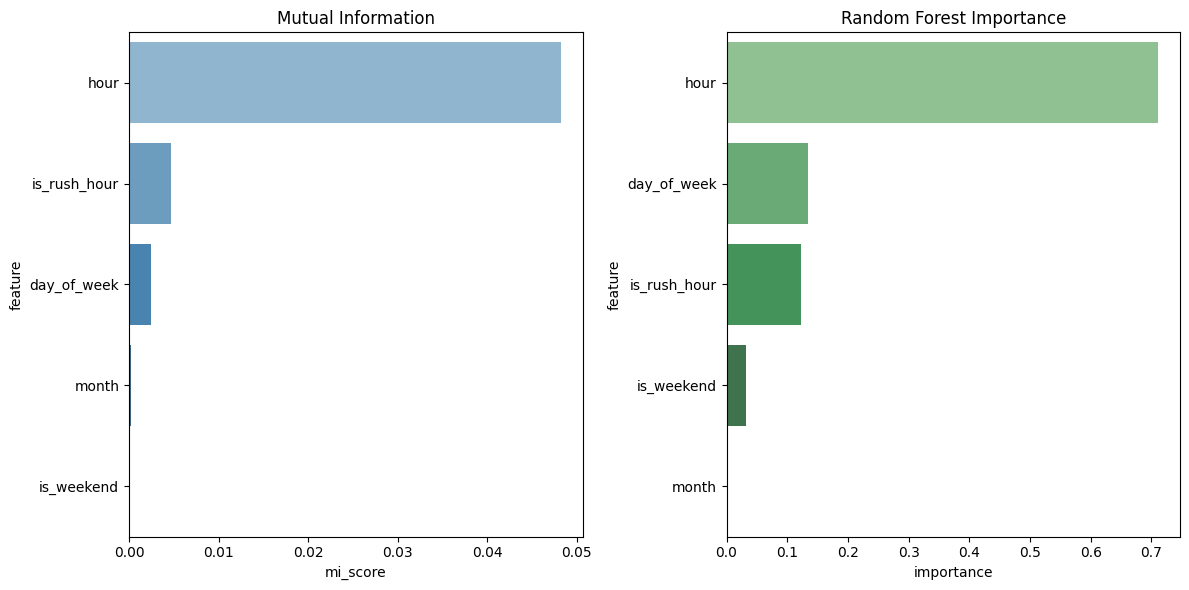

In [18]:
# Plot both rankings side by side as horizontal bar charts
fig, axes = plt.subplots(1, 2, figsize=(12,6))
sns.barplot(x='mi_score', y='feature', data=mi_scores, ax=axes[0], palette='Blues_d')
axes[0].set_title('Mutual Information')
sns.barplot(x='importance', y='feature', data=rf_importances, ax=axes[1], palette='Greens_d')
axes[1].set_title('Random Forest Importance')
plt.tight_layout()
plt.show()

**Reasoning — What do the rankings tell you?**

*(Replace this text. Answer: Which features score highest in both methods? Are there any disagreements between mutual information and RF importance — and if so, why might that be? Are there any features you expected to rank highly but didn't?)*

---
## Section 7 — Final Feature List

Based on everything above, define the exact set of features you will engineer and use in modelling. This list becomes the contract between your EDA and your `src/features.py` implementation.

In [20]:
# Define your final feature list
FINAL_FEATURES = [
    'PULocationID',  # zone id — primary spatial key
    'hour',
    'day_of_week',
    'is_weekend',
    'is_rush_hour',
    'month',
    'lag_1h',
    'lag_24h',
    'rolling_mean_3h',
    'passenger_count',
    'trip_distance'
]

# Feature documentation (how_computed, business justification, leakage risk)
feature_doc = {
    'hour': {
        'business_justification': 'Captures diurnal patterns (commute, nightlife).',
        'leakage_risk': 'None — known at prediction time.'
    },
    'day_of_week': {
        'business_justification': 'Weekday vs weekend differences in travel behaviour.',
        'leakage_risk': 'None.'
    },
    'is_rush_hour': {
        'business_justification': 'Captures predictable demand peaks during commuting windows.',
        'leakage_risk': 'None.'
    },
    'lag_1h': {
        'business_justification': 'Recent demand is the strongest predictor of near-term demand.',
        'leakage_risk': 'None if computed using only past data at prediction time.'
    },
    'lag_24h': {
        'business_justification': 'Captures daily seasonality (same-hour yesterday).',
        'leakage_risk': 'None.'
    },
}

# Print the table for review
print(f'Final feature count: {len(FINAL_FEATURES)}')
print(f'Features: {FINAL_FEATURES}')
display(pd.DataFrame.from_dict(feature_doc, orient='index'))

Final feature count: 11
Features: ['PULocationID', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'month', 'lag_1h', 'lag_24h', 'rolling_mean_3h', 'passenger_count', 'trip_distance']


,business_justification,leakage_risk
hour,"Captures diurnal patterns (commute, nightlife).",None — known at prediction time.
day_of_week,Weekday vs weekend differences in travel behav...,None.
is_rush_hour,Captures predictable demand peaks during commu...,None.
lag_1h,Recent demand is the strongest predictor of ne...,None if computed using only past data at predi...
lag_24h,Captures daily seasonality (same-hour yesterday).,None.


**Summary — Feature decisions:**

*(Replace this text. Write 3–5 sentences summarising: how many features you selected, which category most of them fall into (temporal, lag-based, geographic), which candidate features you rejected and why, and whether any feature carries leakage risk that you decided to accept or reject.)*

---

**Commit this notebook before leaving the session:**
```
git add notebooks/02_eda_skeleton.ipynb
git commit -m "eda: complete sections 1-7, feature candidate list finalized"
git push
```